## Сессия 7 - Продвинутая визуализация, Корреляция 

### **Гипотеза:** Время доставки влияет на конечную оцену пользователя

#### Загрузим датафрейм, сформированный из всех таблиц исходного датасета. Произведем приведение типов данных в столбцах содержащих дату и время. 



In [2]:
import pandas as pd 

df_data = pd.read_csv('data_from_notes/full_data.csv', sep = ';')


cols = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'shipping_limit_date', 'review_creation_date', 'review_answer_timestamp']
for col in cols:
    df_data[col] = pd.to_datetime(df_data[col], format = 'mixed')

# Создадим колонку дней доставки, для дальнейшей работы
df_data['delivery_days'] = (df_data['order_delivered_customer_date'] - df_data['order_purchase_timestamp']).dt.days.astype('float32')

# Удалим технические флаги, которые не несут в себе полезной информации
df_data.drop(columns = ['is_delivered', 'confirm', 'conf_&_paid'], inplace = True)

# Создадим флаг, который поможет оставить только те заказы и строки, по которым доставка была действительно произведена, что соответствует цели исследования
df_data['delivered'] = df_data['delivery_days'].notna()

# Оставим только те заказы, доставка которых была произведена и посчитана ранее
df_data = df_data[df_data['delivered']]
df_data = df_data.drop(columns = ['delivered'])

# Отфильтруем данные по дате, так как начальные и конечные месяцы датафрейма имеют неполные данные о месяцах
start_date = '2017-01-01'
end_date = '2018-08-31'

date_mask = (df_data['order_purchase_timestamp'] >= start_date) & (df_data['order_purchase_timestamp'] <= end_date)
data = df_data[date_mask].copy()
# Посмотрим на полученный датафрейм кратко
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 89808 entries, 0 to 92036
Data columns (total 44 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       89808 non-null  object        
 1   customer_id                    89808 non-null  object        
 2   order_status                   89808 non-null  object        
 3   order_purchase_timestamp       89808 non-null  datetime64[ns]
 4   order_approved_at              89796 non-null  datetime64[ns]
 5   order_delivered_carrier_date   89807 non-null  datetime64[ns]
 6   order_delivered_customer_date  89808 non-null  datetime64[ns]
 7   order_estimated_delivery_date  89808 non-null  datetime64[ns]
 8   customer_unique_id             89808 non-null  object        
 9   customer_zip_code_prefix       89808 non-null  int64         
 10  customer_city                  89808 non-null  object        
 11  customer_state      

#### Перейдем к корреляционному анализу. Для того, чтобы мы могли провести его качественно и получить корректные данные нам необходимо выявить выбросы, которые содержат наши данные. Для этого построим ящик с усами, который отобразит выбросы по методу IQR

##### Выявим выбросы и отобразим их на ящике с усами. Выбросы будут выявляться при помощи метода IQR

Краткая сводка в текстовом представлении:
count    89808.000000
mean        11.950929
std          9.409304
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        208.000000
Name: delivery_days, dtype: float64


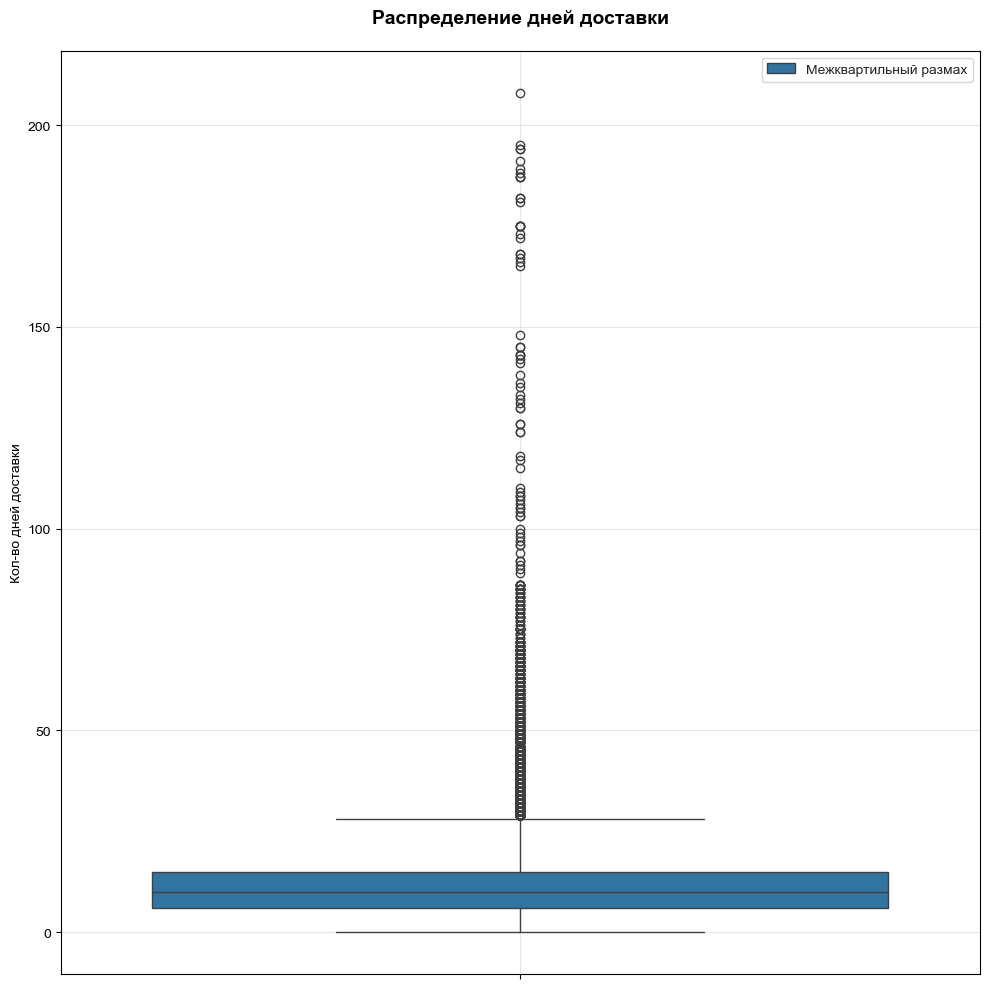

In [3]:
# Построим ящик с усами
import matplotlib.pyplot as plt
import seaborn as sns
# Применим кастомное оформление визуализаций
from style import setup_style, decorate

fig, ax = plt.subplots(figsize = (10, 10))
setup_style()

sns.boxplot(y = data['delivery_days'], ax = ax, label = 'Межквартильный размах')
decorate(ax, 'Распределение дней доставки', '', 'Кол-во дней доставки')
plt.tight_layout()
print(f"Краткая сводка в текстовом представлении:\n{data['delivery_days'].describe()}")


#### Как видно, в данных содержится значительное количество выбросов (Около 5% от общего числа заказов). Так как из прошлых исследований мы знаем, что данные выбросы не являются ошибками данных, а являются реальными кейсами, то исключать их из дальнейшего анализа не стоит, так как далее, именно выбросы могут подсветить взаимосвязь между интересующими значениями, а также могут помочь подтвердить или опровергнуть гипотезу. К тому же, повторюсь, это не ошибка данных, а значит реальная проблема бизнеса, которая в <u>**данном случае**</u> может быть важна

* **Первичный вопрос: Выяснить, влияет ли время доставки на конечную оценку пользователя**
* **Вторичный вопрос: Влияет стоимость заказа на скорость доставки, влияет ли стоимость доставки на её скорость**

c:\Users\User\Analytics-Training\sprint2_olist\work_with_pandas\style.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


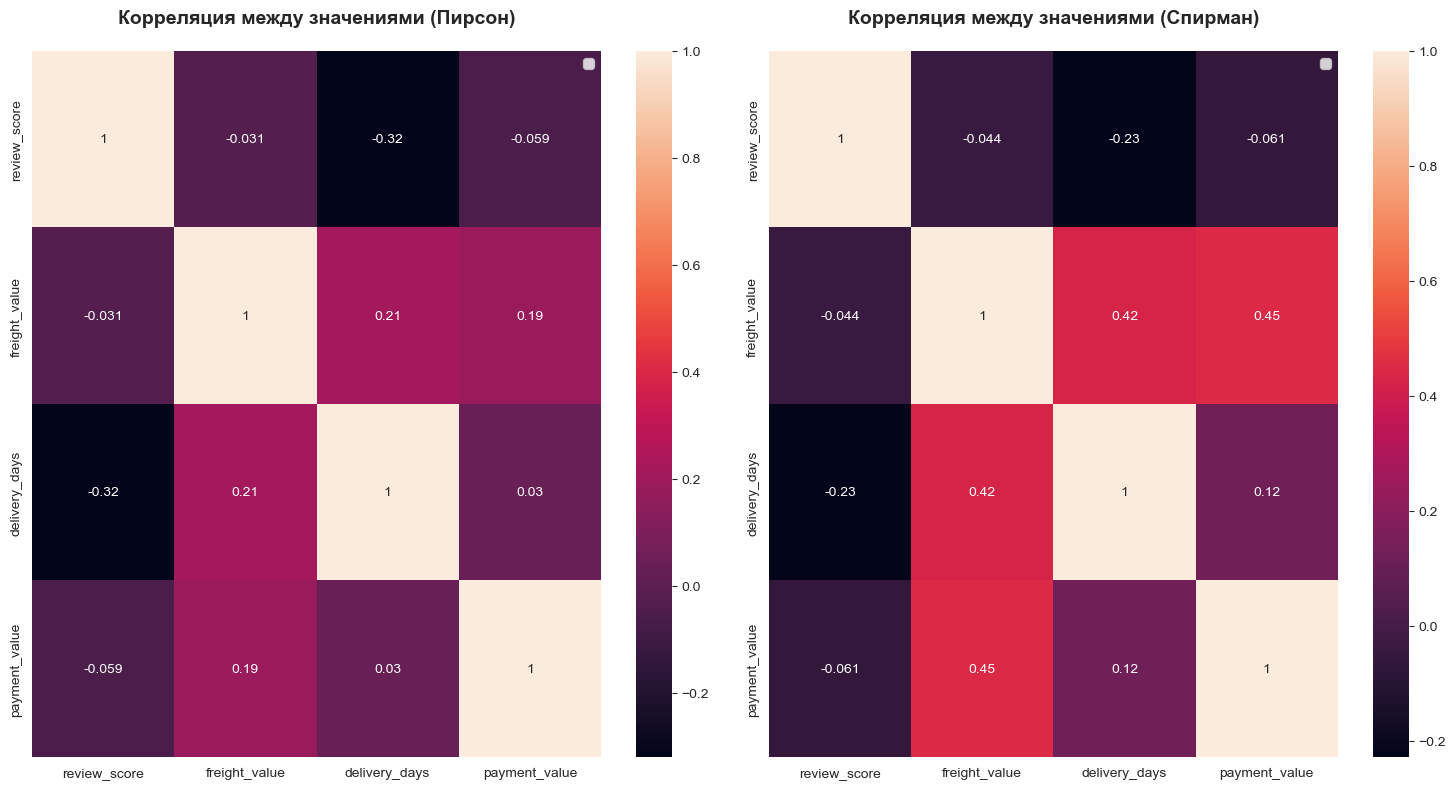

In [4]:
from style import setup_style, decorate
import numpy as np
# Для ответа на интересующие вопросы необходимо взять из оснвного датафрейма необходмые столбцы и сгруппировать их для вычисления общей суммы каждого заказа.
cols_needed = ['order_id', 'customer_unique_id', 'payment_value', 'review_score', 'freight_value', 'delivery_days']
for_cor_data = data[cols_needed].copy()
grouped_data = for_cor_data.groupby(['order_id', 'customer_unique_id', 'review_score', 'freight_value', 'delivery_days'])['payment_value'].sum().reset_index()

# Для рассчета корреляции уберем из полученного датафрейма все текстовые столбцы.
cols = ['review_score', 'freight_value', 'delivery_days', 'payment_value']
corr_data = grouped_data[cols].copy()

#Построим тепловую карту для первичного выявления взаимосвязей между интересующими значениям.
corr_matrix = corr_data.corr()
corr_matrix_spearman = corr_data.corr(method = 'spearman')

setup_style()
fig, (ax, ax1) = plt.subplots(1, 2, figsize=(15, 8))
sns.heatmap(corr_matrix, annot=True, ax=ax)
sns.heatmap(corr_matrix_spearman, annot=True, ax=ax1)
decorate(ax, 'Корреляция между значениями (Пирсон)', '', '')
decorate(ax1, 'Корреляция между значениями (Спирман)', '', '')
plt.tight_layout()


#### После построения тепловых карт, основанных на корреляционных матрицах, построенных по методу Спирмана и Пирсона можно сделать предварительные выводы
##### **Метод Пирсона действительно исказил некоторые коэфиценты. Так, метод Пирсона значительно занизил коэффициент корреляции (КК) у payment_value <-> freight_value, delivery_days <-> freight_value, что может говорить о нелийной связи между этими значениями, которые были плохо перехвачены с помощью метода Пирсона. Однако, взаимосвязь по главной гипотезе, наоборот, лучше выражена при рассчете методом Пирсона, что может говорить о линейной зависимости, а также о том, что выбросы оказались действительно важны, так как Спирман вероятно сгладил значительные выбросы.**
##### Инсайты по полученным данным:
* **После рассчета двумя методами можно сказать, что главная гипотеза, предварительно, подтвердилась и между временем доставки и конечной оценкой пользователя есть умеренная связь. Требуется дальнейшее исследование**
* **Неожиданно, умеренная корреляция наблюдается между стоимостью доставки и cроком доставки. Причем значения показывает, что чем более долгая доставка, тем больше и цена, что является весьма интересным. Требуется дальнейшее исследование**
* **Ожидаемая умеренная корреляция между стоимостью заказа и стоимостью доставки. Стоит предположить, что данная взаимосвязь обусловлена исключительно логистическими издержками. Чем больше заказ -> тем больше места он занимает -> тем дороже его перевозка** 

**Перейдем к подробному разбору первой метрики, а именно - ислледование взаимосвязи между временем доставки и конечной оценки пользователя**

Выше, при построении тепловой карты былов выяснено, что при измерение корреляции по Спирмену и Пирсону значения отличается. Для фиксирования значений проведем рассчет повторно с использованием библиотеки scipy

In [5]:
from scipy.stats import pearsonr, spearmanr

#Посчитаем коэффициент корреляции Пирсона и Спирмена

pearson_r, pearson_p = pearsonr(corr_data['delivery_days'], corr_data['review_score'])
spearman_r, spearman_p = spearmanr(corr_data['delivery_days'], corr_data['review_score'])

# Выведем результат для наглядного сравнения
print('=Сравнение взаимосвязи между количеством дней доставки и конечной оценкой пользователя. Разница между Пирсоном и Спирменом=\n')
print(f"Коэффициент корреляции (КК) Пирсона: {pearson_r:.2f}, p_value (Пирсон): {pearson_p:.3e}")
print(f"Коэффициент корреляции (КК) Спирмана: {spearman_r:.2f}, p_value (Пирсон): {spearman_p:.3e}\n")
print(f"Разнциа между КК Пирсона и Спирмана: {abs(pearson_r - spearman_r):.2f}")



=Сравнение взаимосвязи между количеством дней доставки и конечной оценкой пользователя. Разница между Пирсоном и Спирменом=

Коэффициент корреляции (КК) Пирсона: -0.32, p_value (Пирсон): 0.000e+00
Коэффициент корреляции (КК) Спирмана: -0.23, p_value (Пирсон): 0.000e+00

Разнциа между КК Пирсона и Спирмана: 0.09


Как и говорилось ранее, разница между Пирсоном и Спирманом весьма значительна. Это могло произойти из-за того, что в данных содержаться весьма ценные выбросы, которые Спирман мог сгладить, в связи с его методологией рассчета (по рангам), в то время, как Пирсону удалось лучше поймать взаимосвязь. Возможно связь представлена линейной, нежели монотонной 

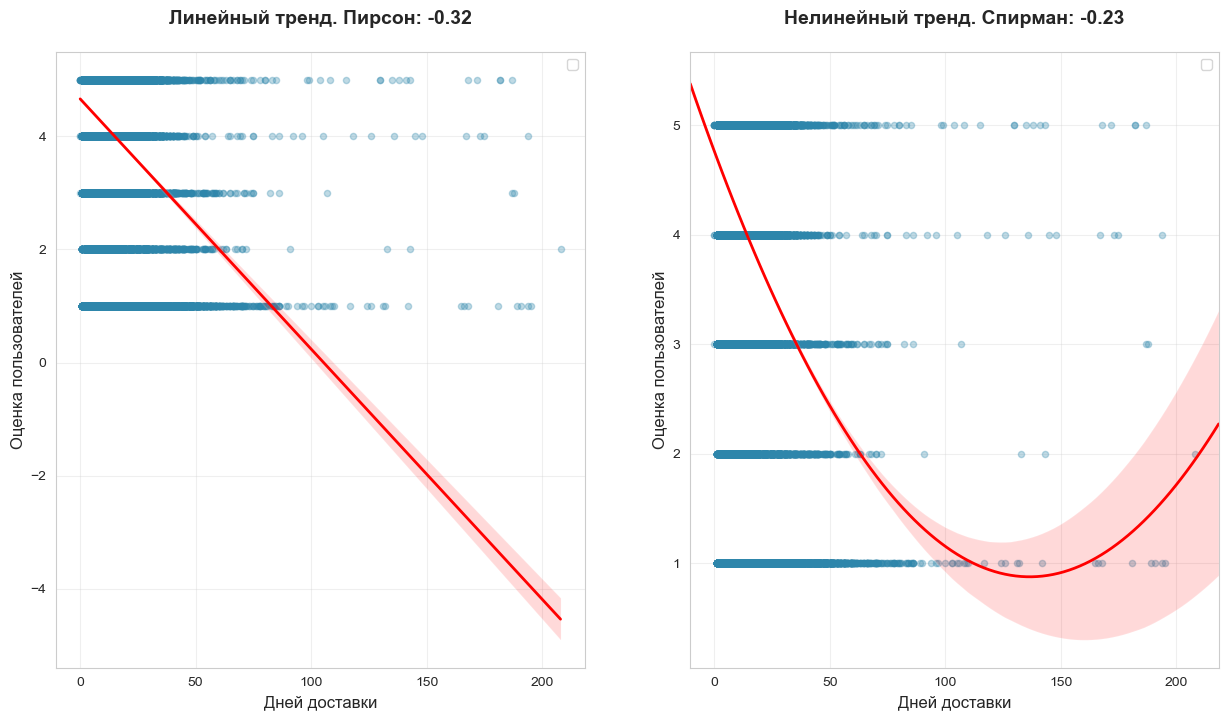

In [6]:
# Построим диаграмму рассеивания с трендом с цель выяснить тип связи между переменными
from style import setup_style, decorate

setup_style()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 8))
#Построим линейный тренд (За это отвечает параметр order = 1 (полином 1-й степени))
sns.regplot(data = corr_data, x = 'delivery_days', y = 'review_score', scatter_kws = {'alpha': 0.3, 's': 20}, line_kws = {'color': 'red', 'linewidth': 2}, order = 1, ax = ax1)
decorate(ax1, f'Линейный тренд. Пирсон: {pearson_r:.2f}', 'Дней доставки', 'Оценка пользователей')
plt.grid(True, alpha = 0.3)
#Построим нелинейный тренд (Полином 2-й степени)
sns.regplot(data = corr_data, x = 'delivery_days', y = 'review_score', scatter_kws = {'alpha': 0.3, 's': 20}, line_kws = {'color': 'red', 'linewidth': 2}, truncate = False, order = 2, ax = ax2)
decorate(ax2, f'Нелинейный тренд. Спирман: {spearman_r:.2f}', 'Дней доставки', 'Оценка пользователей')
plt.grid(True, alpha = 0.3)


Построенные диаграммы наглядно показывают: Мы имеем умеренную связь между временем доставки и оценкой пользователя. Также, диаграммы показывают четкий тренд на падение. Пирсон четко отражает отрицательную связь и говорит о том, что задержка доставки явно портит рейтинг. Однако, график Спирмана, в данном случае, имея КК меньший, чем у Спирмана (0.23) говорит нам больше и отражает то, что связь не является идеально линейной. Также, диаграмма (Спирман) говорит о том, что первые дни задержки (До 50 дней) наиболее сильно влияют на снижение рейтинга, после чего темп падения тренда несколько замедляется и достигает минимум в диапазоне 100-150 дней доставки. Также, при экстримальных задержках сильно возрастает доверительный интервал , что объясняется тем, что выборка становится очень маленькой. Также, при экстримальных задержках поведение пользователя становится несколько хаотичной (Встречаются оценки, как 1 так и 2), что визуально ломает тренд. При этом, конечно же, это не говорит о том, что после длительности доставки в 150 дней покупатели становятся довольнее, они и так максимально недовольны, а возрастание тренда - свидетельство малой выборки в экстримальных значениях и хаотичное поведение пользователей, обращаться внимание на рост тренда после 150 дней. Также, стоит отметить, что вероятная причина того, что метод Спирмана занизил являются именно эти экстримальные значения, которые несколько нарушают порядок при расссчете КК и делают связь менее четкой. 
**Фокус внимания должен быть на первых 30-60 днях, так как в это время лояльность теряется больше всего**

**Далее** необходимо конкретизировать полученные данные и понять, до какого дня оценки дня и где находится тот самый поорог после которого оценки начинают лететь вниз. Конкретизировать рассчеты необходимо также, для того, чтобы перейти от выводов, сделанным по графикам, которые, стоит признать, были весьма неточными к более точным значениям

In [7]:
# Рассчитаем среднюю оценку для каждого дня доставки
delivery_impact = corr_data.groupby('delivery_days').agg({'review_score': ['mean', 'count', 'std']}).reset_index()
delivery_impact.columns = ['delivery_days', 'mean_score', 'count_scores', 'std_score']

# Основываясь на полученных ранее результатах отфильтруем те дни, где количество оценок менее 10
delivery_impact = delivery_impact[delivery_impact['count_scores'] > 10]

# Для примера выведем среднюю оценку пользователей по первым 15-ти дням доставки
print(delivery_impact.head(15))

    delivery_days  mean_score  count_scores  std_score
1             1.0    4.461538          1274   1.057876
2             2.0    4.438967          2556   1.061233
3             3.0    4.384989          3091   1.125731
4             4.0    4.394395          3925   1.095291
5             5.0    4.356461          4713   1.126275
6             6.0    4.337148          5505   1.139941
7             7.0    4.367055          6089   1.112188
8             8.0    4.339084          5391   1.121568
9             9.0    4.269366          4841   1.185723
10           10.0    4.276947          4481   1.183339
11           11.0    4.250000          4128   1.188549
12           12.0    4.249320          3674   1.167164
13           13.0    4.197212          3443   1.211879
14           14.0    4.207023          2990   1.196187
15           15.0    4.148503          2505   1.248443


Небольшой вывод: Видно, что в первые 15 дней в целом ничего не происодит и оценка держится. Однако, стандартное оклонение начинает гулять слегка сильнее, но незначительно (Изменение около одной десятой)

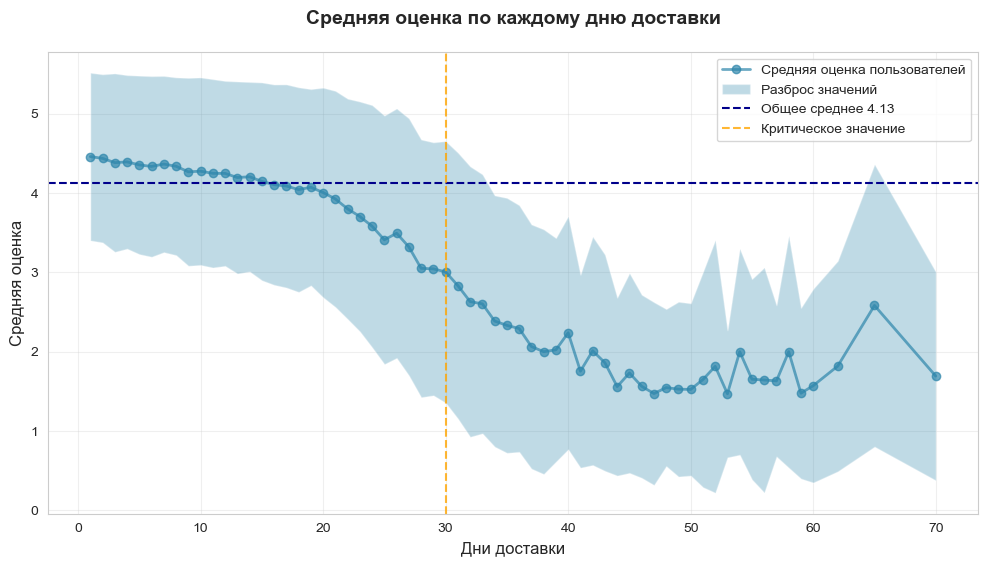

In [8]:
# Визуализируем полученные данные
fig, ax = plt.subplots(figsize = (12, 6))
setup_style()
plt.plot(delivery_impact['delivery_days'], delivery_impact['mean_score'], marker = 'o', linewidth = 2, alpha = 0.7, label = 'Средняя оценка пользователей')
plt.fill_between(delivery_impact['delivery_days'], delivery_impact['mean_score'] - delivery_impact['std_score'], delivery_impact['mean_score'] + delivery_impact['std_score'],
                 alpha = 0.3, label = 'Разброс значений')
general_mean = corr_data['review_score'].mean()
plt.axhline(y = general_mean, color = 'darkblue', linestyle = '--', label = f'Общее среднее {general_mean:.2f}')
plt.axvline(x = 30, color = 'orange', linestyle = '--', alpha = 0.8, label = 'Критическое значение')
decorate(ax, 'Средняя оценка по каждому дню доставки', 'Дни доставки', 'Средняя оценка')
plt.legend()
plt.grid(True, alpha = 0.3)


Также, перед тем, как делать выводы исследуем выбросы отдельно

In [9]:
#Основываясь на ящике с усами, который был показан выше отделиим выбросы от 30-го дня
normal = corr_data[corr_data['delivery_days'] < 30].copy()
outliers = corr_data[corr_data['delivery_days'] >= 30].copy()
print('Сравнение нормальных заказов и заказов с выбросами\n')
print('Нормальные заказы')
print(f"Количество заказов: {len(normal)}. В процентном соотношении от общего числа: {len(normal)/len(corr_data)*100:.2f}%")
print(f"Средняя оценка: {normal['review_score'].mean():.2f}")
print(f"Корреляция:\nПирсон: {pearsonr(normal['delivery_days'], normal['review_score'])}\nСпирман: {spearmanr(normal['delivery_days'], normal['review_score'])}\n")
print('Проблемные')
print(f"Количество заказов: {len(outliers)}. В процентном соотношении от общего числа: {len(outliers)/len(corr_data)*100:.2f}%")
print(f"Средняя оценка: {outliers['review_score'].mean():.2f}")
print(f"Корреляция:\nПирсон: {pearsonr(outliers['delivery_days'], outliers['review_score'])}\nСпирман: {spearmanr(outliers['delivery_days'], outliers['review_score'])}")



Сравнение нормальных заказов и заказов с выбросами

Нормальные заказы
Количество заказов: 73348. В процентном соотношении от общего числа: 95.52%
Средняя оценка: 4.22
Корреляция:
Пирсон: PearsonRResult(statistic=-0.17564783455515193, pvalue=0.0)
Спирман: SignificanceResult(statistic=-0.15557560192757044, pvalue=0.0)

Проблемные
Количество заказов: 3441. В процентном соотношении от общего числа: 4.48%
Средняя оценка: 2.25
Корреляция:
Пирсон: PearsonRResult(statistic=-0.08130195792017977, pvalue=1.7939508921719217e-06)
Спирман: SignificanceResult(statistic=-0.25695285875084517, pvalue=5.172721476530025e-53)


#### Итоговые выводы о гипотезе: 
После проведеныых исследований взаимосвязь между днями доставки и снижением оценки была доказана. Мы увидели умеренную отрицательную корреляцию, т.е. чем дольше товар доставляют тем больше падает рейтинг. При этом связь в данном случае нелинейна, что показывает диаграмма рассеивания + тренд, который был показан выше. Также, было выяснено, что критическое время доставки 30 дней. После данной отметки оценки пользователей безвозратно летят в низ. Также, доставка 30+ дней является выбросом. Это доказывает боксплот, представленный выше, а также средние показатели оценки, представленные на графике. Подытожим: **В данном случае мы имеем высокозначимую умеренную отрицательную корреляцию с нелинейной зависимостью** При этом, стоит отметить, что сила связи умеренно-слабая, поэтому нужно понимать, что на снижение рейтинга влияют другие факторы, которые не были сейчас отображены.


**Инсайт для бизнеса: В целом, можно сказать, что компания успешно доставляет товары. 95.52% доставок до 30 дней и средняя оценка тому подтвреждение. Корреляцию на уровне -0.18 можно интерпретировать как то, что на данном этапе покупатели терпеливы и даже при доставке около месяца (В меньшую сторону) могут поставить хорошую оценку. Такое ожидание не сказывается на репутации. НО! Если доставка задерживается и длиться от 30 дней, то рейтинг резко обваливается и далее составляет 2.25, а также подтверждается тем, что корреляция Пирсона 0.08, то есть линейная связь почти исчезает, что говорит о том, что оценки перестают активно падать в низ, так как покупатели уже максимально недовольны, связь становится нелинейной. В итоге: Бизнесу необходимо исключить ситуации, при которых доставка занимает 30+ дней, так как такая долгая доставка создает активную аудиторию хейтеров, которая может испортить имидж площадки и компании и привести к потери потенциальных клиентов и это при том, что мы знаем, что у площадки проблемы с удержанием клиентов. Предлагается ввести KPI, где проблемная доставка не должна преодолевать порог 1% от общего числа заказов** 

#### Проверка остальных гипотез


**Проверка взаимосвязи между временем доставки и стоимостью доставки**

In [10]:
# Вычислим корреляцию и p_value для пары freight_value и delivery_days 
spearman_r, spearman_p = spearmanr(corr_data['freight_value'], corr_data['delivery_days'])
print(f'Корреляция между временем доставки и стоимотсью доставки: {spearman_r:.2f}')
print(f'Вероятность того, что значение случайно: {spearman_p:.3e}')

Корреляция между временем доставки и стоимотсью доставки: 0.42
Вероятность того, что значение случайно: 0.000e+00


Как видно, мы имеем дело с умеренной положительной корреляцией, которая наверняка не является случайной. Также, предполагаем, что связь имеет нелинейную зависимость, так как именно рассчет корреляции Спирмана дает такой уверенный уровень

Построим диаграмму рассеяния, которая будет дополнена линией тренда, для лучшей наглядности и интерпретацией полученных данных

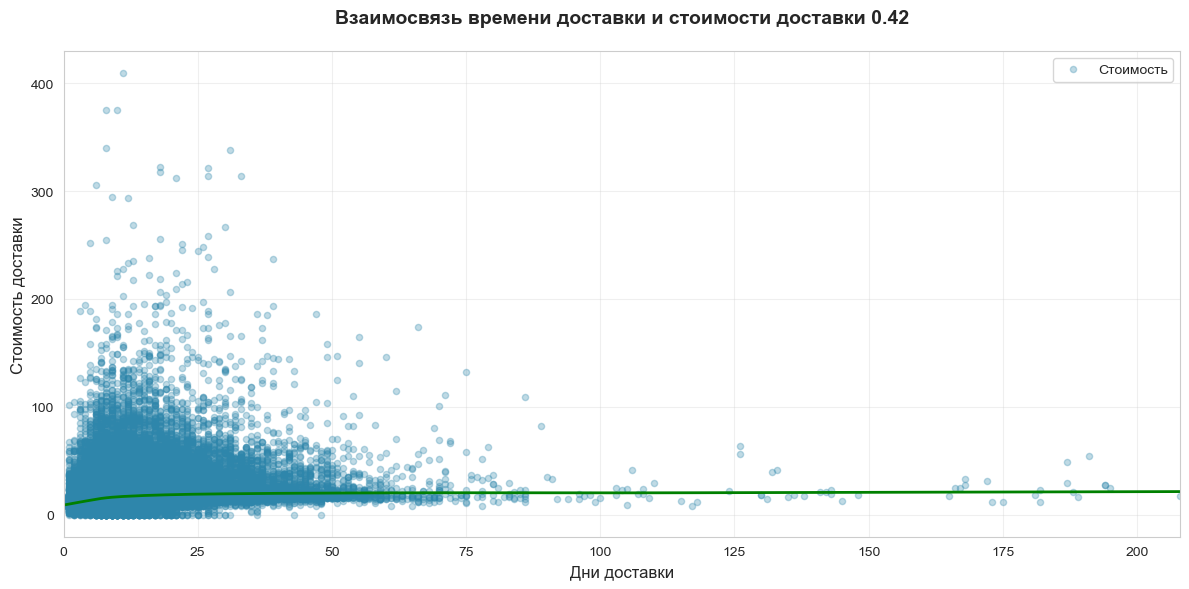

In [11]:
setup_style()
fig, ax = plt.subplots(figsize=(12, 6))

sns.regplot(data = corr_data, x = 'delivery_days', y = 'freight_value', line_kws = {'color': 'green', 'linewidth': 2},
             scatter_kws ={'s': 20, 'alpha': 0.3}, lowess = True, truncate = False, label = 'Стоимость', ax = ax)
decorate(ax, f'Взаимосвязь времени доставки и стоимости доставки {spearman_r:.2f}', 'Дни доставки', 'Стоимость доставки')
plt.tight_layout()
plt.grid(True, alpha = 0.3)

Как видно, график читается весьма трудно и визуально может даже противоречить положительной корреляции. Но, по графику можно сказать, что до 30-ти дней имеется огромное количество почти бесплатных доставок, в то время как после 30 дней стоимость доставки отрывается от нуля и находится в районе 20-50, что подтверждает положительную корреляцию. Очень дорогую доставку (100+) можно объяснить объемным и дорогим грузом, которые физически дорого транспортировать. При этом не стоит обманываться тому, что чем дольше доставка тем больше цена, о чем может намекать корреляция. Долгие доставки не являются рекордно дорогими и человек не платит больше за долгую доставку. Необходимо продолжить исследование для более точных выводов.

In [12]:
print(f"Средняя цена до 30 дней: {corr_data[corr_data['delivery_days'] < 30]['freight_value'].median():.2f}")
print(f"Средняя цена после 100 дней: {corr_data[corr_data['delivery_days'] > 100]['freight_value'].median():.2f}\n")

Средняя цена до 30 дней: 16.18
Средняя цена после 100 дней: 21.05



Рассчетом мы доказали вывод о том, что положительная корреляция в данном случае обусловлена тем, что с ростом времени доставки пропадают самые дешевые варианты доставки, значения отрвыаются от нуля, что как бы вызывает рост и положительную корреляцию. Проблема остается - полученная диаграмма рассеяния плохо читается, так как она смазывает заказы с дешевой доставкой и подсвечивает дорогую доставку, тем самым путая наблюдателя, в данном случае нас. Для прояснения картины можно использовать гексоганальный график, ограничив при этом рассматриваемую область, так как предполагается, что основная "жизнь" находится в левом нижнем углу до 50 дней, после чего данные почти отсутствуют. Такое предположение допустимо, так как ранее было выявлено, что основная часть доставок находится в пределах 50 дней, после чего данных мало - редкие выбросы. Также обосновано тем, что выбросов (Более 30 дней) всего 4-5% от общей массы заказов

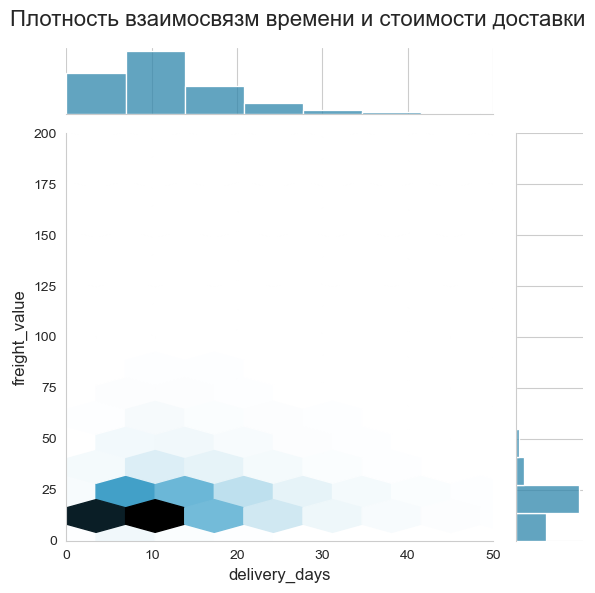

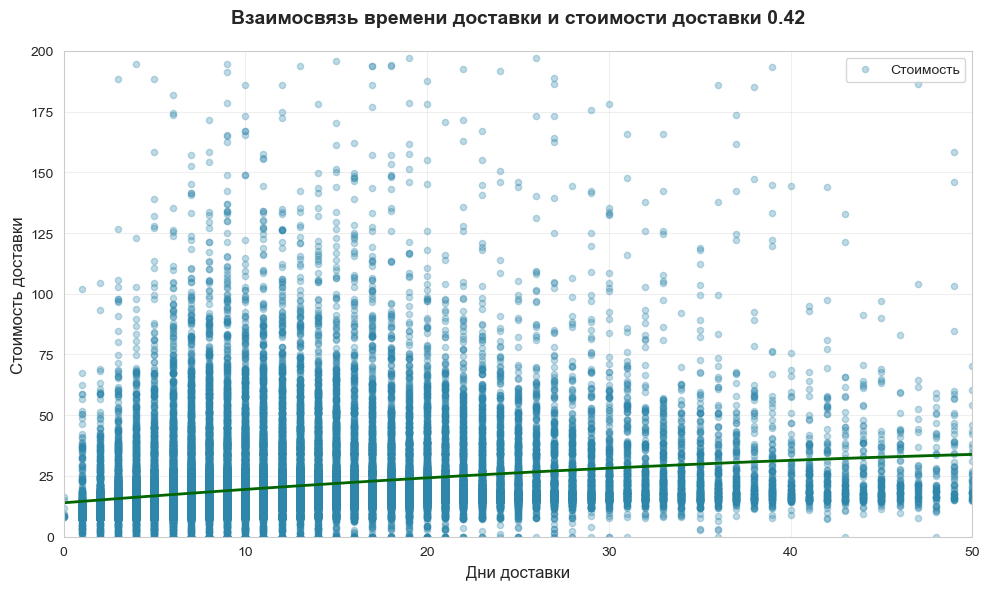

In [13]:
setup_style()
hexsplot = sns.jointplot(data = corr_data, x = 'delivery_days', y = 'freight_value', kind = 'hex', gridsize = 30, marginal_kws = dict(bins = 30, fill = True))
# Ограничим оси x и y для того, чтобы лучше рассмотреть основной массив данных не отвлекаясь на экстремальные значения
hexsplot.ax_joint.set_xlim(0, 50)
hexsplot.ax_joint.set_ylim(0, 200)
plt.subplots_adjust(top = 0.9)
hexsplot.fig.suptitle('Плотность взаимосвязм времени и стоимости доставки', fontsize = 16)
plt.tight_layout()

# Также, сделаем еще раз диаграмму рассеяния, но уже со сжатой областью значений
fig, ax = plt.subplots(figsize = (10, 6))
sns.regplot(data = corr_data, x = 'delivery_days', y = 'freight_value', line_kws = {'color': 'darkgreen', 'linewidth': 2},
             scatter_kws ={'s': 20, 'alpha': 0.3}, order = 2, truncate = False, label = 'Стоимость', ax = ax)
plt.xlim(0, 50)
plt.ylim(0, 200)
decorate(ax, f'Взаимосвязь времени доставки и стоимости доставки {spearman_r:.2f}', 'Дни доставки', 'Стоимость доставки')
plt.tight_layout()
plt.grid(True, alpha = 0.3)



**Выводы** После полученных данных можно с уверенностью сказать, что мы действительно наблюдаем умеренную положительную корреляциию между временем и стоимостью доставки. Она обусловлена тем, что с течением времени пропадают бесплатные и почти бесплатные доставки и остаются в основном доставки со средней стоимостью (20-50) и при этом значения не возвращаются к нулю, при этом, как уже говорилось, ни в коем случае нельзя сделать вывод о том, что чем дольше доставка, тем больше цена. Напротив, самые дорогие доставки в основном сосредоточены вместе с основной массой доставок (Основная масса доставок находится в диапазоне 10-15 дней, что подтверждает гексагональная диаграмма). Это связано с тем, что скорее всего это были или дорогие товары или товары, которые дорого доставлять (Объемные, тяжелые) из-за чего сумма доставки оказалась значительной. И при этом, для бизнеса здесь проблем не существует - все долгие доставки, это по сути, доставки со средней стоимостью, которые были доставлены сверх всяких сроков из-за логистических проблем. 

**Не инсайт, но рекомендация бизнесу**: Так как мы видим, что очень долгие доставки были оплачены и при этом пользователи крайне недовольны (Обычно очень низкий рейтинг у долгих доставок, что было выяснено выше), рекомендуется вернуть деньги за долгую доставку, чтобы хоть и немного но снизить ущерб имиджу компании

Наблюдается умеренная связь (0.42), обусловленная географическим фактором: на длинных дистанциях отсутствуют сверхдешевые тарифы, что «поднимает пол» стоимости до 20-50 единиц. При этом самые дорогие доставки (100+) не связаны с задержками, а являются следствием специфики груза (вес/объем).
Бизнес-рекомендация:
Учитывая выявленный ранее критический порог в 30 дней (после которого рейтинг падает ниже 3.0), рекомендуется внедрить систему автоматического возврата стоимости доставки при превышении этого срока. Поскольку такие заказы не являются «рекордно дорогими» для компании, финансовые потери от возврата будут значительно ниже, чем репутационный ущерб от крайне недовольных клиентов.

#### Последняя гипотеза
Ожидаемая корреляция между стоимостью заказа и стоимостью доставки обусловлена тем, что дорогие товары чаще являются дорогими в перевозке из-за физических признаков (Веса, объема) или же к ним применяется более бережная доставка, в том числе более качественная упаковка и тому подобное. Данная взаимосвязь не будет рассмотрена подробно так как она имеет ту же природу, что и взаиомсвязь, рассмотренная ранее

### Дальнейшее исследование взамосвязи времени доставки и оценки пользователя

**Рассмотрим топ-10 категорий, которые наиболее подвержены задержкам**

In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 89808 entries, 0 to 92036
Data columns (total 44 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       89808 non-null  object        
 1   customer_id                    89808 non-null  object        
 2   order_status                   89808 non-null  object        
 3   order_purchase_timestamp       89808 non-null  datetime64[ns]
 4   order_approved_at              89796 non-null  datetime64[ns]
 5   order_delivered_carrier_date   89807 non-null  datetime64[ns]
 6   order_delivered_customer_date  89808 non-null  datetime64[ns]
 7   order_estimated_delivery_date  89808 non-null  datetime64[ns]
 8   customer_unique_id             89808 non-null  object        
 9   customer_zip_code_prefix       89808 non-null  int64         
 10  customer_city                  89808 non-null  object        
 11  customer_state      

In [46]:
#Сгурппируем данные и найдем самые проблемные категории
grouped_data = data.groupby('product_category_name').agg(
    median_delivery = ('delivery_days', 'median'),
    q90 = ('delivery_days', lambda x: x.quantile(0.9)),
    mean_score = ('review_score', 'mean'),
    count_outliers = ('delivery_days', lambda x: (x > 30).sum()),
    total_orders = ('order_id', 'count')
)
grouped_data['outliers_percent'] = (grouped_data['count_outliers'] / grouped_data['total_orders'] * 100).round(2)

top_problems = grouped_data.sort_values(by = 'q90', ascending = False).head(10)
print(f' Самые проблемные категории:{top_problems}')


 Самые проблемные категории:                                median_delivery   q90  mean_score  \
product_category_name                                               
moveis_escritorio                          19.0  34.0    3.542433   
casa_conforto_2                             9.5  33.5    3.538462   
fashion_underwear_e_moda_praia             11.0  28.0    4.069307   
audio                                      10.0  25.0    3.850340   
fashion_roupa_feminina                     10.0  25.0    3.861111   
relogios_presentes                         10.0  24.0    4.049460   
instrumentos_musicais                      10.0  24.0    4.193896   
fashion_calcados                           13.0  24.0    4.263415   
consoles_games                             10.0  23.8    4.151717   
cine_foto                                   9.0  23.4    4.253968   

                                count_outliers  total_orders  outliers_percent  
product_category_name                                         

Как видно, разбор по категориям подтверждает взаимосвязь между сроком доставки и оценкой пользователей. Особенно ярко это показывают категории "Товары для дома" и "Мебель для дома и офиса". В этих категориях не так много заказов, в сравнении с остальными, однако доставка в них очень нестабильна. Так медианный срок доставки у "Мебели для дома" - 19 дней, при этом, каждый десятый ждет больше 34 дней, а 90% людей получают свой заказ в срок до 34 дней. Это почти в 2 раза больше, чем медианное значение, а процент просроченных заказов 13,15% - это огромное значение. Такая же ситуация наблюдается и в категории товаров для дома. Также, стоит отметить категорию  "Relogos Presents", которая, казалось бы не отличается низким рейтингом или же большим количеством выбросов. Однако в абсолютном значении выбросов, среди нашего анти-топа она занимает первое место. Количество выбросов 226, доставка весьма нестабильна (Каждый 10 ждет больше 24 дней), что сильно сказывается на оценке, так как люди ожидают получить подарки обычно в положенный срок и склонны очень расстраиваться. **При этом, компании стоит обратить особое внимание к этой категории, так как в 2017-2018 году эта категория входила в топ-5 категорий по продажам среди всех категорий и компания не может себе позволить терять рейтинг данной категории долгой и крайне нестабильной доставкой**

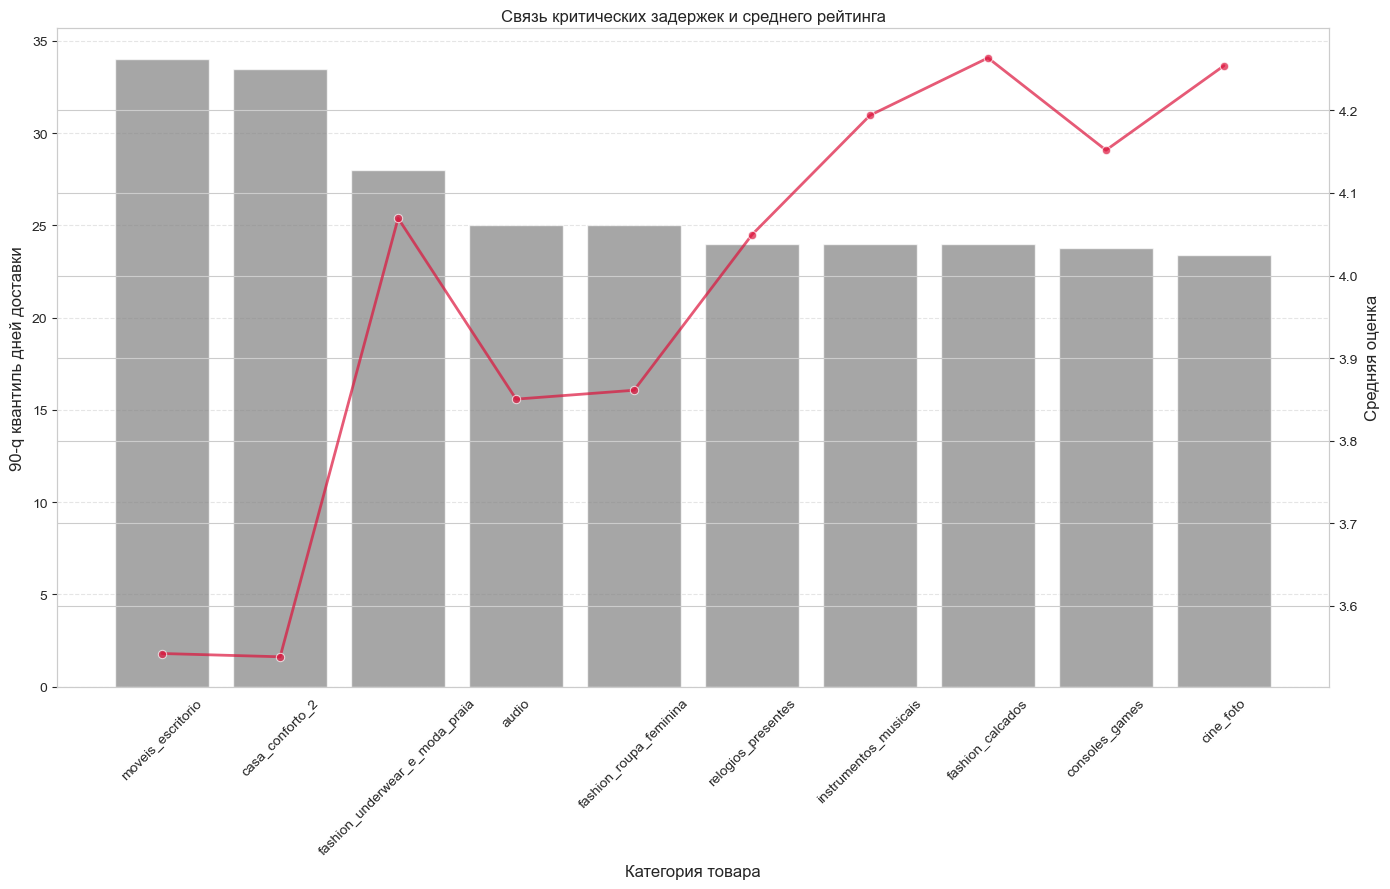

In [60]:
# Построим визуализацию, демонстрирующую выводы
setup_style()

fig, ax1 = plt.subplots(figsize = (14, 9))

sns.barplot(x = top_problems.index, y = top_problems['q90'], alpha = 0.7, color = 'gray', ax = ax1)
ax1.set_ylabel('90-q квантиль дней доставки', fontsize = 12, labelpad = 5)
ax1.set_xlabel('Категория товара', fontsize = 12, labelpad = 5)
ax1.set_title('Связь критических задержек и среднего рейтинга', fontsize = 12, pad = 5)
ax1.tick_params(axis = 'x', rotation = 45)
ax1.grid(axis = 'y', linestyle = '--', alpha = 0.5)

ax2 = ax1.twinx()
sns.lineplot(x = top_problems.index, y = top_problems['mean_score'], color = 'crimson', alpha = 0.7, linewidth = 2, marker = 'o', ax = ax2)
ax2.set_ylabel('Средняя оценка', fontsize = 12, labelpad = 5)

plt.tight_layout()

На графике видно, что как и отмечалось ранее, категории с нестабильной и долгой доставкой имеют низкие рейтинги. Однако стоит отметить категорию нижнего белья, в ней рейтинг подскакивает выше 4, что может быть связано с тем, что людям важнее было получить качественную вещь, чем скорость доставки. Это косвенно подтверждает количество заказов (101). Категория часы и подарки также имеет достаточно высокий рейтинг. Но не будем забывать о прошлых выводах - При внешнем благополучии данная категория создает сотни недовольных покупателей, которых не видно за общим количетством заказов. Также мы видим, что как только 90-йквантиль перестает достигать и превышать 25 дней, то средний рейтинг поднимается выше 4 и не опускается в дальнейшем

In [61]:
corr_data = top_problems['q90'].corr(top_problems['mean_score'], method = 'spearman')
print(f'Коэффицент корреляции Спирмана: {corr_data:.2f}')

Коэффицент корреляции Спирмана: -0.80


Как и говорилось ранее, несмотря на специфику отдельных категорий, коэффициент корреляции Спирмана составляет -0.80, что подтверждает сильную статистическую зависимость между ростом критических задержек и падением удовлетворенности клиентов.


**Далее по имеющимся данным исследуем, как менялась ситуация с доставкой с течением времени**

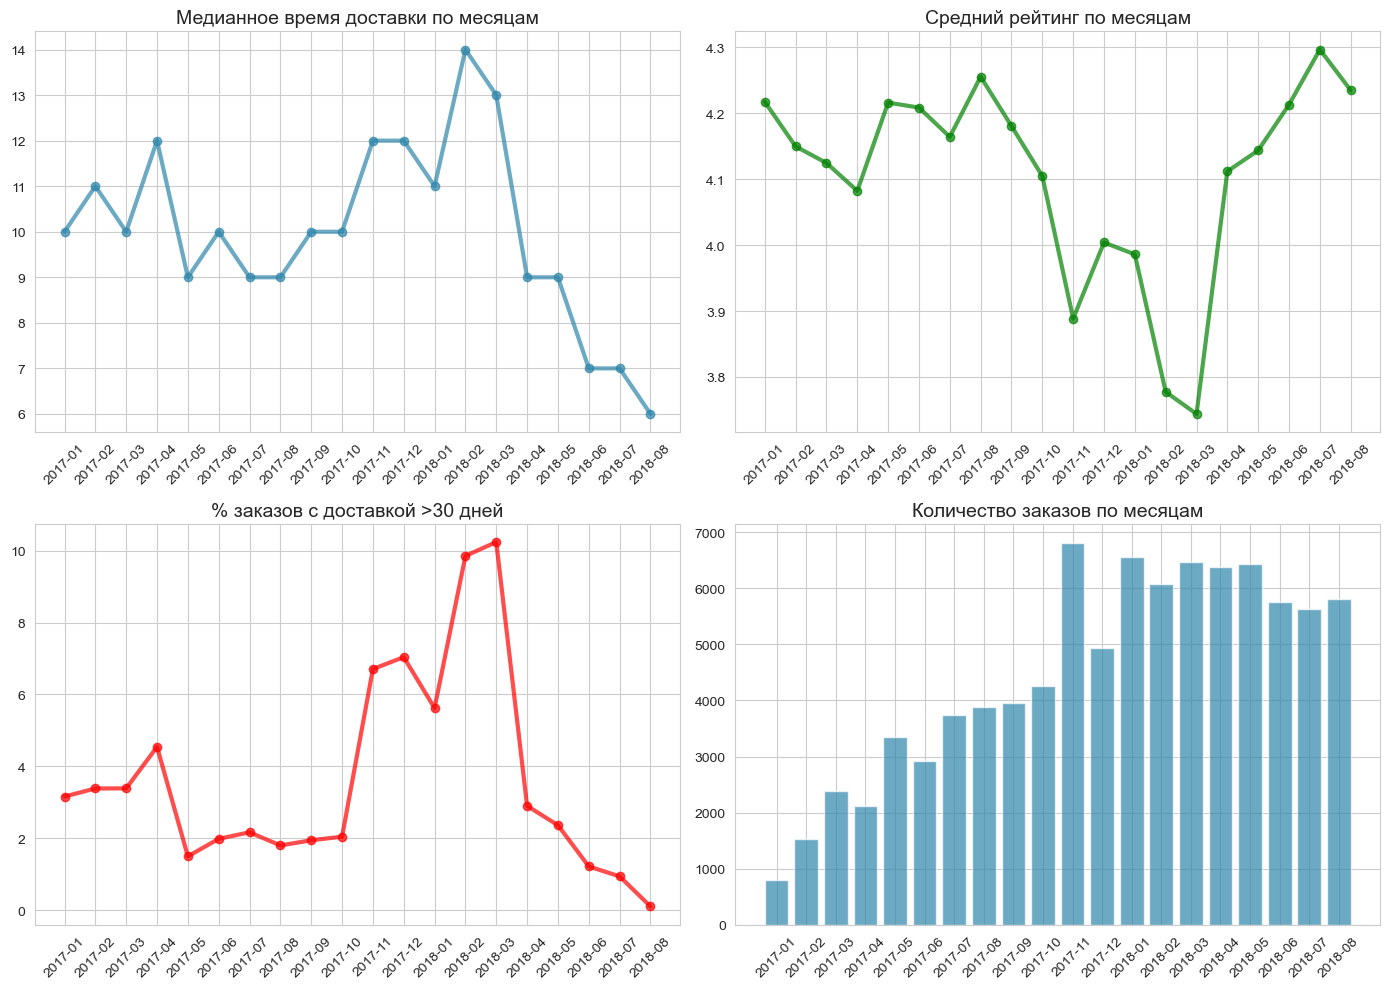

In [65]:
# Создаём колонку с месяцем заказа
data['order_month'] = data['order_purchase_timestamp'].dt.to_period('M')

# Агрегируем по месяцам
monthly_stats = data.groupby('order_month').agg(
    median_delivery=('delivery_days', 'median'),
    mean_score=('review_score', 'mean'),
    count_orders=('order_id', 'count'),
    late_pct=('delivery_days', lambda x: (x > 30).mean() * 100)
).reset_index()

# Визуализация
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
setup_style()

# Медиана доставки
axes[0, 0].plot(monthly_stats['order_month'].astype(str), monthly_stats['median_delivery'], marker='o', alpha = 0.7, linewidth = 3)
axes[0, 0].set_title('Медианное время доставки по месяцам')
axes[0, 0].tick_params(axis='x', rotation=45)

# Средний рейтинг
axes[0, 1].plot(monthly_stats['order_month'].astype(str), monthly_stats['mean_score'], marker='o', color='green', alpha = 0.7, linewidth = 3)
axes[0, 1].set_title('Средний рейтинг по месяцам')
axes[0, 1].tick_params(axis='x', rotation=45)

# Процент просроченных доставок (>30 дней)
axes[1, 0].plot(monthly_stats['order_month'].astype(str), monthly_stats['late_pct'], marker='o', color='red', alpha = 0.7, linewidth = 3)
axes[1, 0].set_title('% заказов с доставкой >30 дней')
axes[1, 0].tick_params(axis='x', rotation=45)

# Количество заказов
axes[1, 1].bar(monthly_stats['order_month'].astype(str), monthly_stats['count_orders'], alpha = 0.7)
axes[1, 1].set_title('Количество заказов по месяцам')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()

На графиках видно, что основное количество проблем вызвал подъем спроса и заказов, что нарушило доставку и привело к значительному снижению средних оценок, после чего, компании удалось наладить логистику и средние оценки снова начали расти. Однако, можно предположить, что возникшая проблема с доставкой весьма сильно испортило имидж компании. Об этом может косвенно свидетельствовать замедление и в дальнейшем падение числа заказов. Возможно проблема в том, что часть старой клиентской базы ушла, а потенциальных новых клиентов оттолкнула недавний провал компании

**Попробуем построить простую модель линейной регрессии, чтобы понимать, насколько сильно 1 медианный день доставки снижает среднюю оценку. А также посмотрим, какой процент случаев описывает данная зависимость**

In [71]:
import statsmodels.api as sm

reg_data = grouped_data[['median_delivery', 'mean_score']].dropna()

X = sm.add_constant(reg_data['median_delivery'])
y = reg_data['mean_score']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             mean_score   R-squared:                       0.171
Model:                            OLS   Adj. R-squared:                  0.159
Method:                 Least Squares   F-statistic:                     14.83
Date:                Sun, 05 Apr 2026   Prob (F-statistic):           0.000252
Time:                        16:40:11   Log-Likelihood:                -16.947
No. Observations:                  74   AIC:                             37.89
Df Residuals:                      72   BIC:                             42.50
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               4.7333      0.172     

Регрессионный анализ показал статистически значимую отрицательную связь между медианным временем доставки и средним рейтингом (β = -0.068, p < 0.001). Каждый дополнительный день доставки снижает оценку клиентов в среднем на 0.068 пункта. Несмотря на статистическую значимость модели, R² = 0.17 указывает на то, что время доставки объясняет лишь 17% вариации рейтингов, что подчеркивает важность учета дополнительных факторов качества сервиса.